In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/viral-social-media-trends-and-engagement-analysis/Viral_Social_Media_Trends.csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/kaggle/input/viral-social-media-trends-and-engagement-analysis/Viral_Social_Media_Trends.csv')
df

,Post_ID,Platform,Hashtag,Content_Type,Region,Views,Likes,Shares,Comments,Engagement_Level
0,Post_1,TikTok,#Challenge,Video,UK,4163464,339431,53135,19346,High
1,Post_2,Instagram,#Education,Shorts,India,4155940,215240,65860,27239,Medium
2,Post_3,Twitter,#Challenge,Video,Brazil,3666211,327143,39423,36223,Medium
3,Post_4,YouTube,#Education,Shorts,Australia,917951,127125,11687,36806,Low
4,Post_5,TikTok,#Dance,Post,Brazil,64866,171361,69581,6376,Medium
...,...,...,...,...,...,...,...,...,...,...
4995,Post_4996,YouTube,#Education,Video,Japan,4258236,381509,59209,4674,High
4996,Post_4997,Instagram,#Education,Video,UK,4841525,166266,54841,4832,Medium
4997,Post_4998,YouTube,#Fashion,Shorts,USA,2004080,32401,75229,33875,Low
4998,Post_4999,Instagram,#Gaming,Shorts,Canada,2221665,46996,12954,42832,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Post_ID           5000 non-null   object
 1   Platform          5000 non-null   object
 2   Hashtag           5000 non-null   object
 3   Content_Type      5000 non-null   object
 4   Region            5000 non-null   object
 5   Views             5000 non-null   int64 
 6   Likes             5000 non-null   int64 
 7   Shares            5000 non-null   int64 
 8   Comments          5000 non-null   int64 
 9   Engagement_Level  5000 non-null   object
dtypes: int64(4), object(6)
memory usage: 390.8+ KB


In [6]:
df.shape

(5000, 10)

<Axes: xlabel='Platform'>

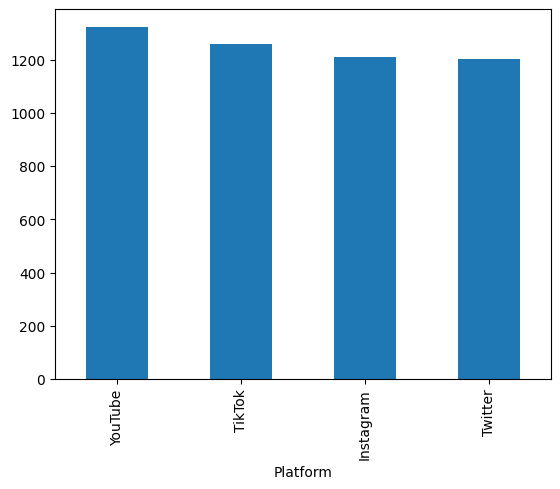

In [7]:
df['Platform'].value_counts().plot(kind='bar')

array([[<Axes: title={'center': 'Views'}>,
        <Axes: title={'center': 'Likes'}>],
       [<Axes: title={'center': 'Shares'}>,
        <Axes: title={'center': 'Comments'}>]], dtype=object)

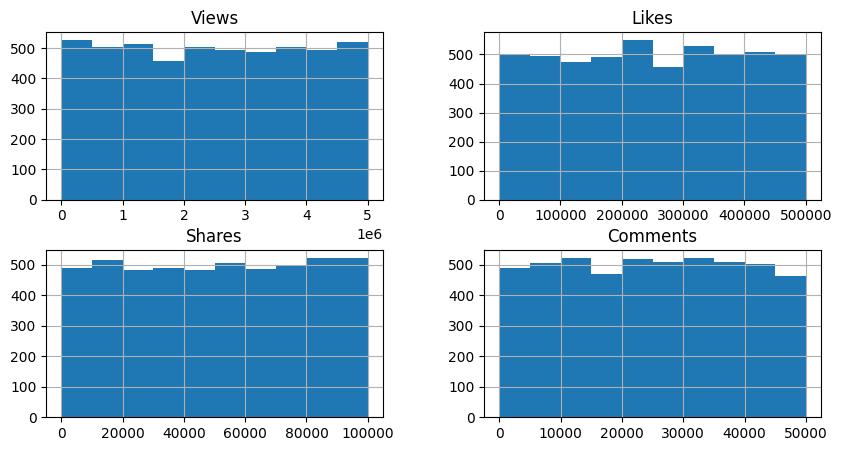

In [8]:
df.hist(figsize=(10,5))

In [9]:
df['Platform'].unique()

array(['TikTok', 'Instagram', 'Twitter', 'YouTube'], dtype=object)

In [10]:
df['Hashtag'].unique()

array(['#Challenge', '#Education', '#Dance', '#Comedy', '#Gaming',
       '#Music', '#Viral', '#Fitness', '#Tech', '#Fashion'], dtype=object)

In [11]:
df['Content_Type'].unique()

array(['Video', 'Shorts', 'Post', 'Tweet', 'Live Stream', 'Reel'],
      dtype=object)

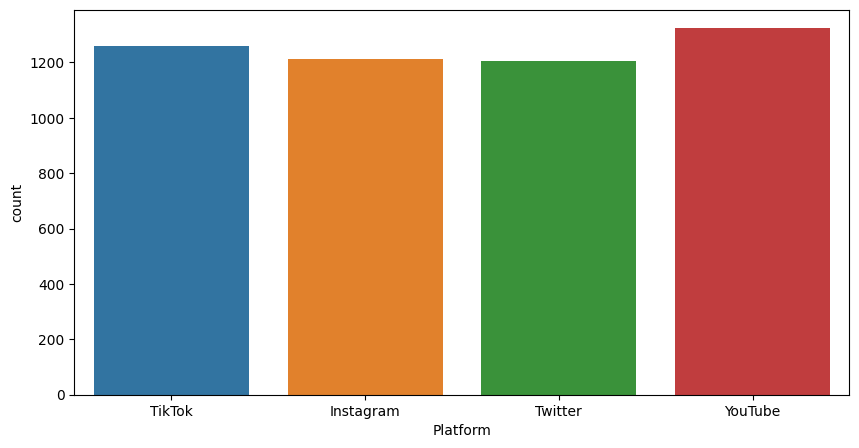

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(x = 'Platform', data=df)
plt.show()

In [13]:
labels = df['Region'].value_counts()
labels

Region
USA          677
Canada       658
UK           647
Brazil       641
India        617
Australia    602
Japan        592
Germany      566
Name: count, dtype: int64

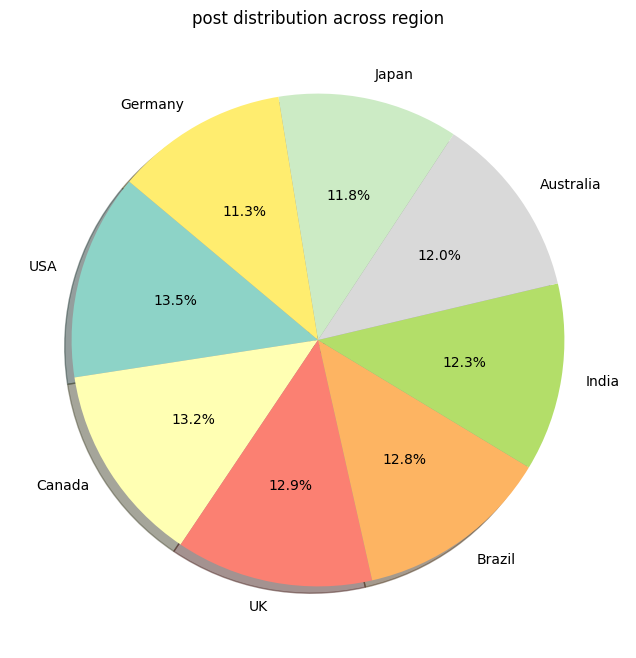

In [14]:
plt.figure(figsize=(10,8))
df['Region'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, cmap='Set3', shadow=True)
plt.title('post distribution across region')
plt.ylabel('')
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

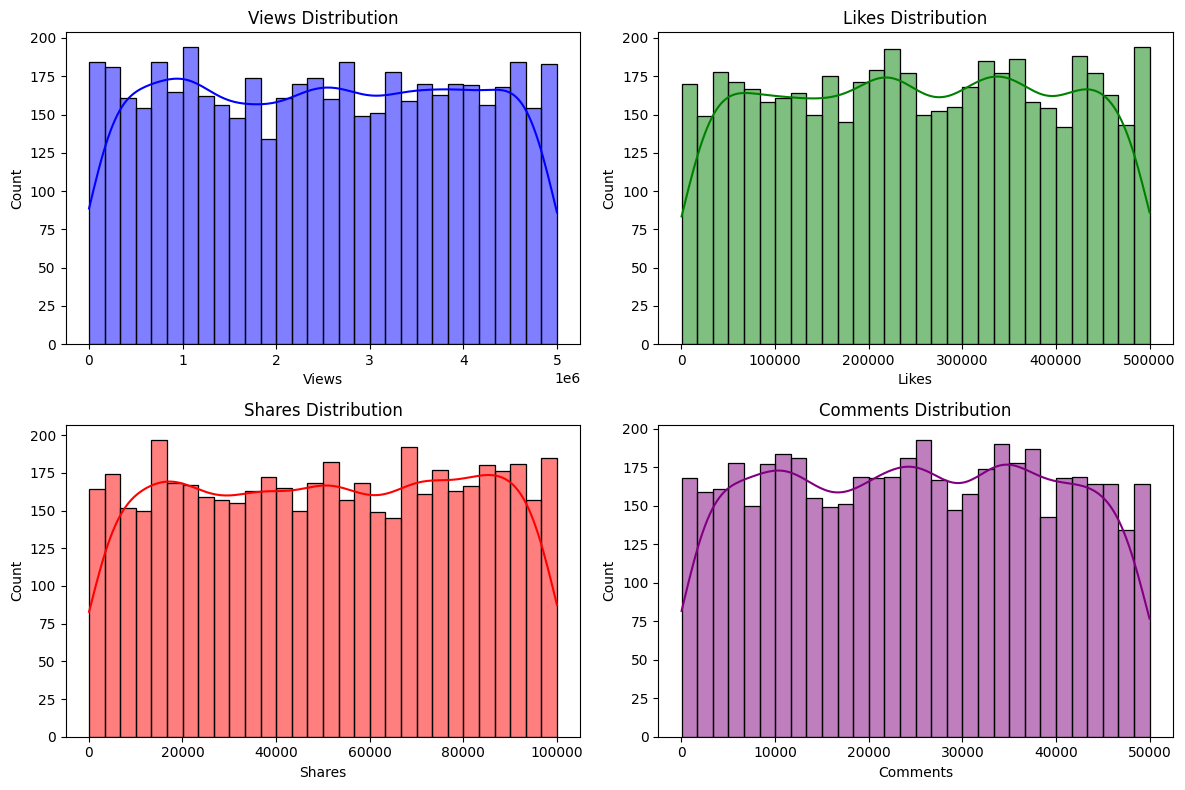

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.histplot(df['Views'], bins=30, ax=axes[0, 0], kde=True, color='blue')
axes[0, 0].set_title("Views Distribution")
sns.histplot(df['Likes'], bins=30, ax=axes[0, 1], kde=True, color='green')
axes[0, 1].set_title("Likes Distribution")
sns.histplot(df['Shares'], bins=30, ax=axes[1, 0], kde=True, color='red')
axes[1, 0].set_title("Shares Distribution")
sns.histplot(df['Comments'], bins=30, ax=axes[1, 1], kde=True, color='purple')
axes[1, 1].set_title("Comments Distribution")
plt.tight_layout()
plt.show()

In [16]:
#popular hashtags on different platforms
df['Hashtag'].value_counts()

Hashtag
#Fitness      536
#Education    525
#Challenge    507
#Comedy       505
#Dance        496
#Music        493
#Tech         491
#Fashion      487
#Viral        481
#Gaming       479
Name: count, dtype: int64

In [18]:
most_viewed = df.loc[df.groupby('Platform')['Views'].idxmax(), ['Platform', 'Post_ID', 'Region', 'Views', 'Hashtag']]
print(most_viewed)

       Platform    Post_ID  Region    Views     Hashtag
1841  Instagram  Post_1842   India  4997766      #Music
3603     TikTok  Post_3604  Brazil  4997284      #Dance
650     Twitter   Post_651  Brazil  4997429  #Challenge
675     YouTube   Post_676  Canada  4999430      #Dance


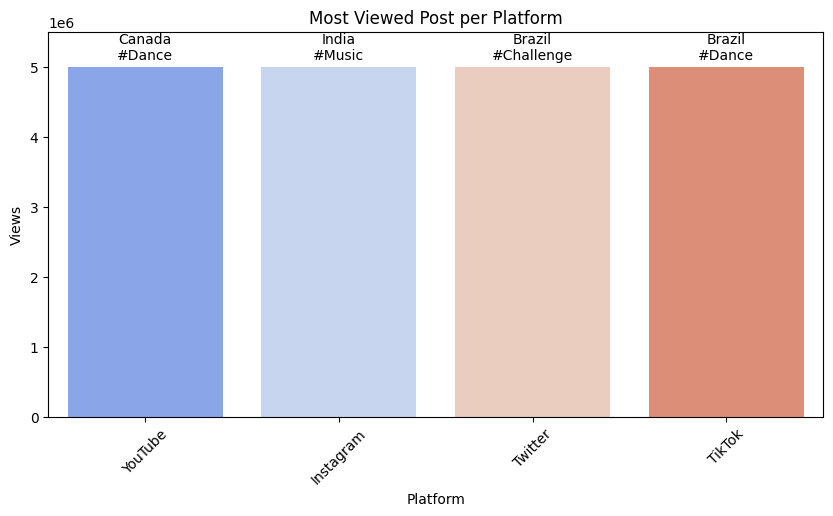

In [19]:
most_viewed = most_viewed.sort_values(by='Views',ascending=False)

plt.figure(figsize=(10,5))
ax = sns.barplot(x = 'Platform',y='Views', data=most_viewed, palette='coolwarm')

for i, (platform, views, region, hashtag) in enumerate(zip(
        most_viewed["Platform"], 
        most_viewed["Views"], 
        most_viewed["Region"], 
        most_viewed["Hashtag"])):

    ax.text(i, views * 1.02, f"{region}\n{hashtag}", ha='center', fontsize=10)

plt.title("Most Viewed Post per Platform")
plt.xlabel("Platform")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.ylim(0, most_viewed["Views"].max() * 1.1) 
plt.show()

1. Engagement Metrics Correlation Analysis

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


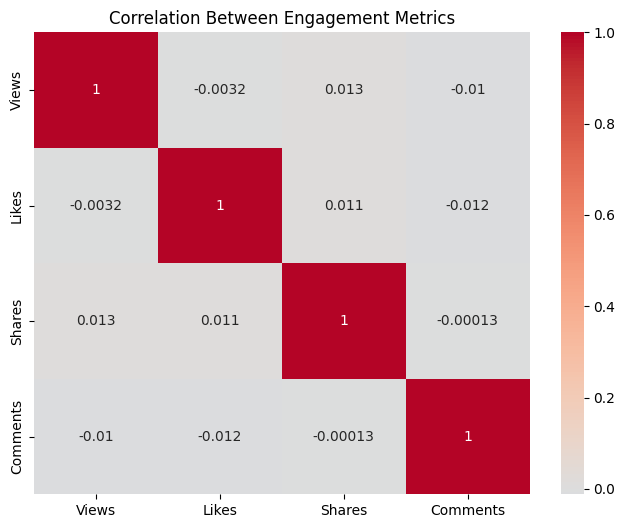

In [20]:
# Calculate correlation between engagement metrics
correlation_matrix = df[['Views', 'Likes', 'Shares', 'Comments']].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Engagement Metrics')
plt.show()

2. Top Performing Hashtags Analysis

<Figure size 1200x600 with 0 Axes>

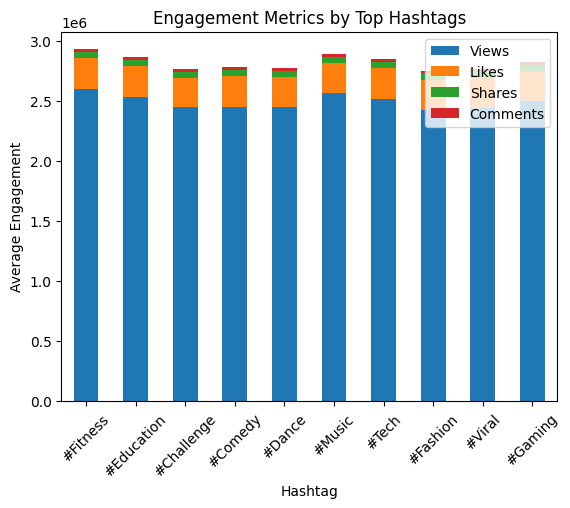

In [21]:
# Top 10 most used hashtags
top_hashtags = df['Hashtag'].value_counts().head(10)

# Engagement metrics by top hashtags
hashtag_engagement = df.groupby('Hashtag')[['Views', 'Likes', 'Shares', 'Comments']].mean()
top_hashtag_engagement = hashtag_engagement.loc[top_hashtags.index]

# Plot
plt.figure(figsize=(12, 6))
top_hashtag_engagement.plot(kind='bar', stacked=True)
plt.title('Engagement Metrics by Top Hashtags')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.show()

3. Content Type Performance Analysis

<Figure size 1000x600 with 0 Axes>

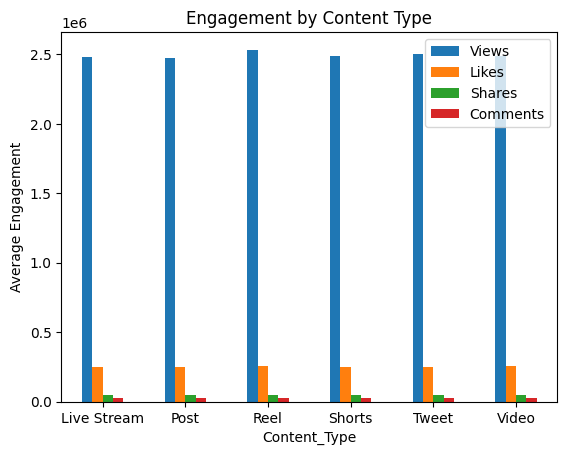

In [22]:
# Engagement by content type
content_engagement = df.groupby('Content_Type')[['Views', 'Likes', 'Shares', 'Comments']].mean()

# Plot
plt.figure(figsize=(10, 6))
content_engagement.plot(kind='bar')
plt.title('Engagement by Content Type')
plt.ylabel('Average Engagement')
plt.xticks(rotation=0)
plt.show()

4. Regional Performance Analysis

<Figure size 1200x600 with 0 Axes>

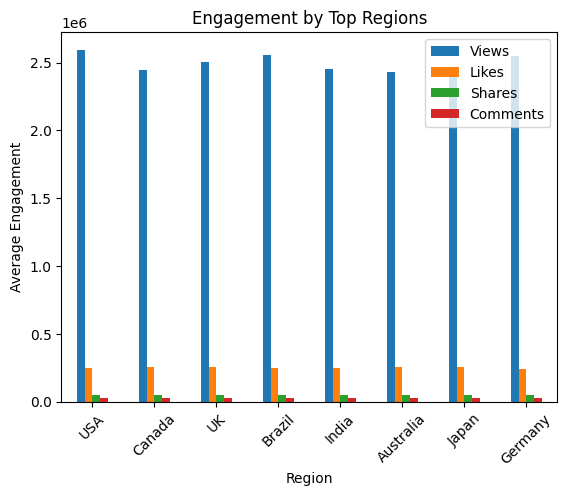

In [23]:
# Top regions by engagement
top_regions = df['Region'].value_counts().head(10).index
region_engagement = df.groupby('Region')[['Views', 'Likes', 'Shares', 'Comments']].mean()
top_region_engagement = region_engagement.loc[top_regions]

# Plot
plt.figure(figsize=(12, 6))
top_region_engagement.plot(kind='bar')
plt.title('Engagement by Top Regions')
plt.ylabel('Average Engagement')
plt.xticks(rotation=45)
plt.show()

5. Engagement Level by Platform

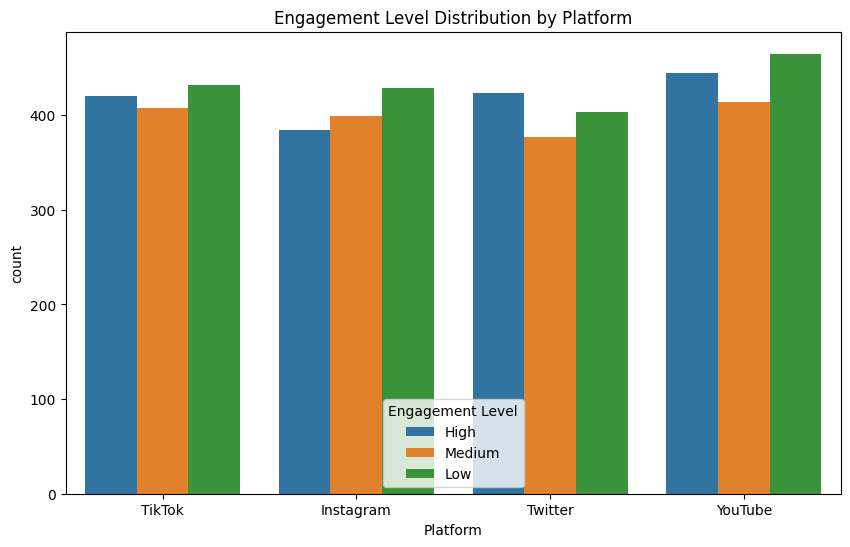

In [24]:
# Engagement level distribution by platform
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Platform', hue='Engagement_Level')
plt.title('Engagement Level Distribution by Platform')
plt.legend(title='Engagement Level')
plt.show()

6. Time Series Analysis (assuming Post_ID indicates time order)

<Figure size 1200x600 with 0 Axes>

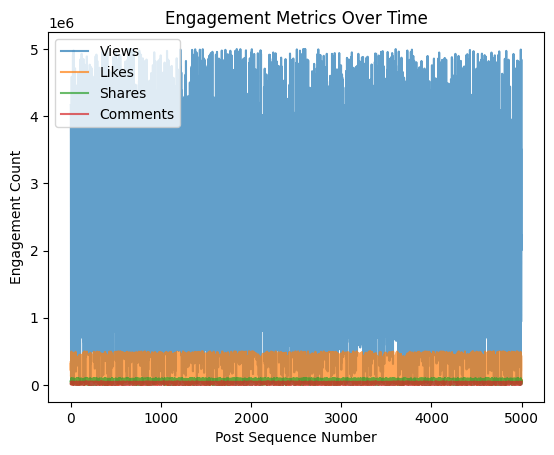

In [25]:
# Convert Post_ID to numerical for time series (assuming sequential posting)
df['Post_Num'] = df['Post_ID'].str.extract('(\d+)').astype(int)

# Plot engagement metrics over time
plt.figure(figsize=(12, 6))
df.sort_values('Post_Num').plot(x='Post_Num', y=['Views', 'Likes', 'Shares', 'Comments'], alpha=0.7)
plt.title('Engagement Metrics Over Time')
plt.xlabel('Post Sequence Number')
plt.ylabel('Engagement Count')
plt.show()

7. Engagement Score Calculation and Analysis

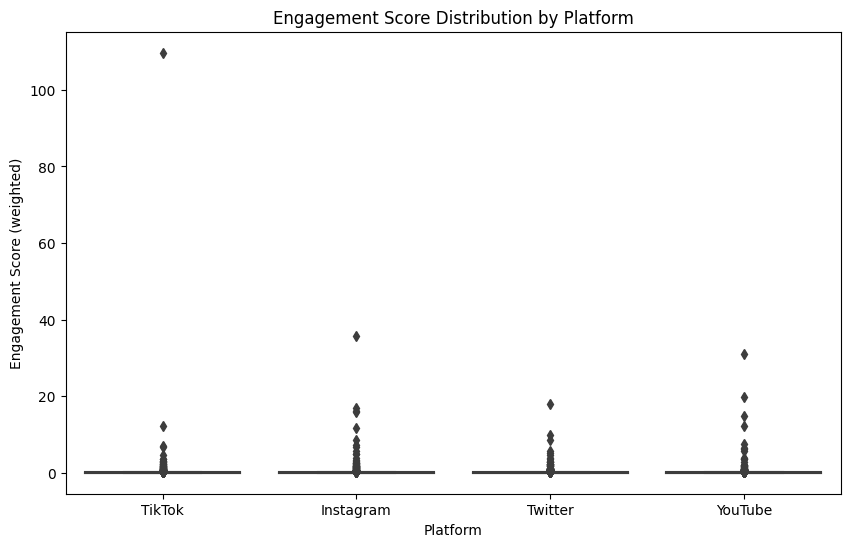

In [26]:
# Calculate a composite engagement score (weighted sum)
df['Engagement_Score'] = (df['Likes'] * 0.4 + df['Shares'] * 0.3 + df['Comments'] * 0.3) / df['Views']

# Top performing posts by engagement score
top_posts = df.nlargest(10, 'Engagement_Score')[['Platform', 'Hashtag', 'Content_Type', 'Engagement_Score']]

# Plot engagement score by platform
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Platform', y='Engagement_Score')
plt.title('Engagement Score Distribution by Platform')
plt.ylabel('Engagement Score (weighted)')
plt.show()

8. Hashtag Network Analysis

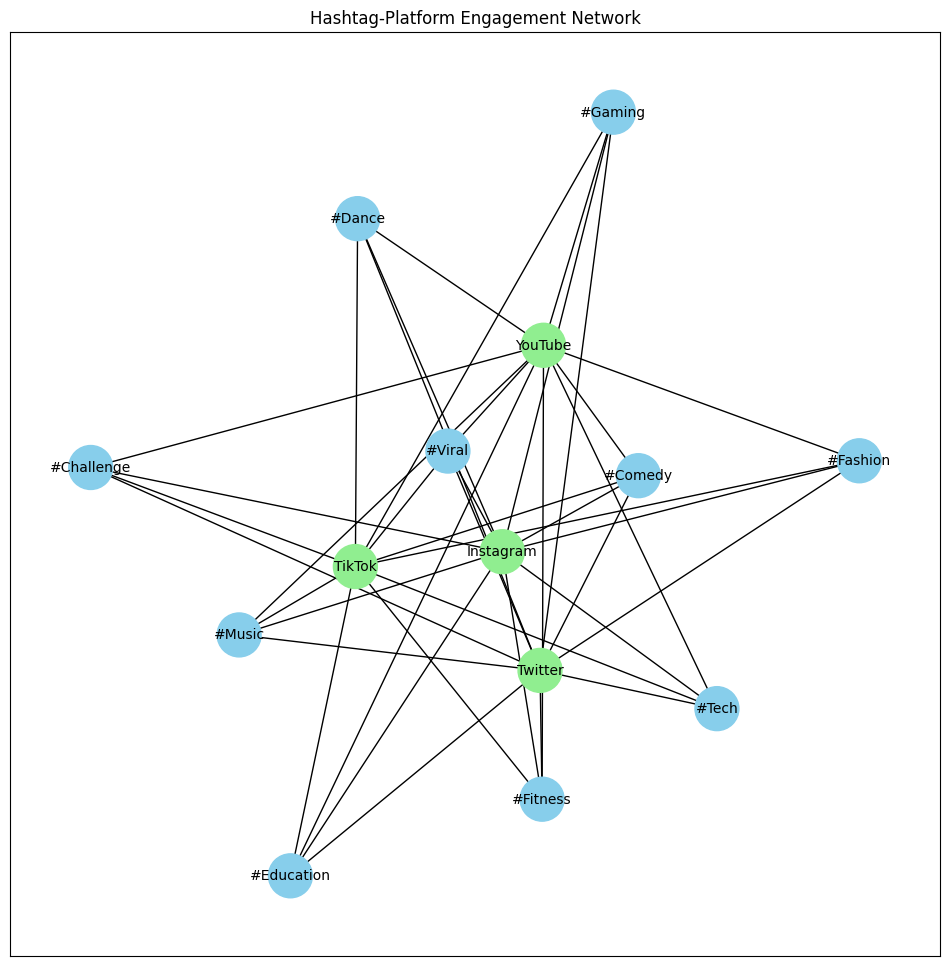

In [27]:
from collections import defaultdict
import networkx as nx

# Create a co-occurrence matrix for hashtags (assuming multiple hashtags per post)
# For this dataset, we'll assume each post has one hashtag, so we'll look at hashtag-platform relationships

# Create a bipartite graph between hashtags and platforms
G = nx.Graph()

# Add nodes and edges
for _, row in df.iterrows():
    G.add_node(row['Hashtag'], bipartite=0)
    G.add_node(row['Platform'], bipartite=1)
    G.add_edge(row['Hashtag'], row['Platform'], weight=row['Engagement_Score'])

# Plot the network
plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw_networkx(G, pos, with_labels=True, node_size=1000, font_size=10, 
                 node_color=['skyblue' if G.nodes[n]['bipartite']==0 else 'lightgreen' for n in G.nodes])
plt.title('Hashtag-Platform Engagement Network')
plt.show()

9. Predictive Model for Engagement Level

              precision    recall  f1-score   support

        High       0.40      0.40      0.40       349
         Low       0.33      0.39      0.36       334
      Medium       0.34      0.28      0.31       317

    accuracy                           0.36      1000
   macro avg       0.36      0.36      0.36      1000
weighted avg       0.36      0.36      0.36      1000



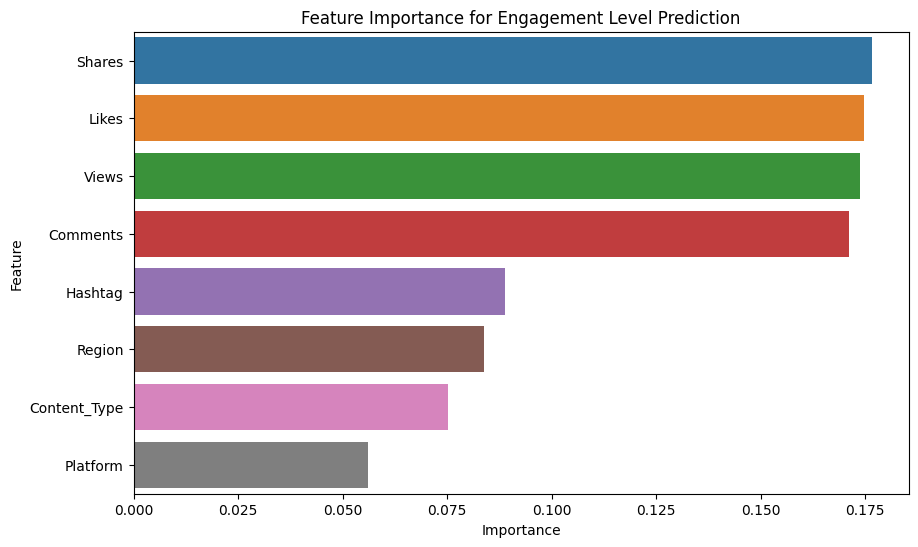

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Prepare data for modeling
le = LabelEncoder()
df_encoded = df.copy()
for col in ['Platform', 'Hashtag', 'Content_Type', 'Region', 'Engagement_Level']:
    df_encoded[col] = le.fit_transform(df[col])

# Features and target
X = df_encoded[['Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments']]
y = df_encoded['Engagement_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance for Engagement Level Prediction')
plt.show()

10. Clustering Analysis of Posts

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

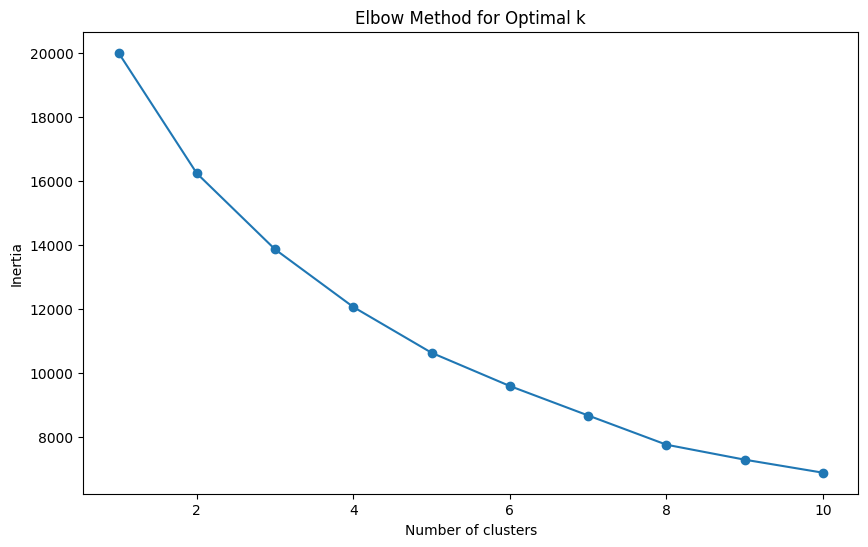

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


                Views          Likes        Shares      Comments
Cluster                                                         
0        3.862466e+06  246825.780098  67831.143120  23778.803440
1        1.132040e+06  260556.156785  69831.904480  25979.479578
2        2.407660e+06  248122.186084  19505.867314  24969.378101


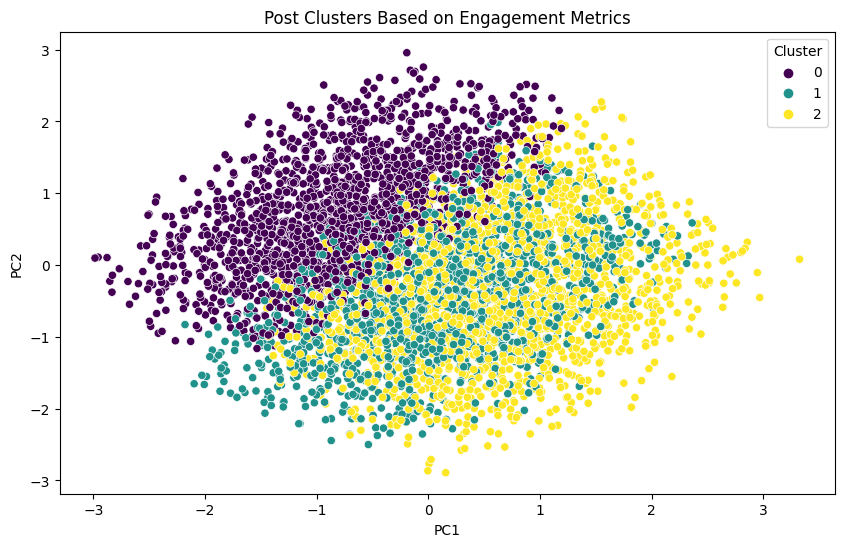

In [29]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare data for clustering
cluster_data = df[['Views', 'Likes', 'Shares', 'Comments']]
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Determine optimal number of clusters using elbow method
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

# Apply K-means clustering (assuming 3 clusters based on engagement levels)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# Analyze cluster characteristics
cluster_analysis = df.groupby('Cluster')[['Views', 'Likes', 'Shares', 'Comments']].mean()
print(cluster_analysis)

# Visualize clusters (PCA for dimensionality reduction)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
principal_components = pca.fit_transform(scaled_data)
df['PC1'] = principal_components[:, 0]
df['PC2'] = principal_components[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='viridis')
plt.title('Post Clusters Based on Engagement Metrics')
plt.show()

•	A comprehensive understanding of how neural computing applications impact social media user behavior and decision-making.

1. Predictive Modeling for Engagement Forecasting

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3249 - loss: 1.1765 - val_accuracy: 0.3130 - val_loss: 1.1113
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3612 - loss: 1.1121 - val_accuracy: 0.3190 - val_loss: 1.1068
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3832 - loss: 1.0932 - val_accuracy: 0.3150 - val_loss: 1.1070
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3784 - loss: 1.0943 - val_accuracy: 0.3330 - val_loss: 1.1080
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3842 - loss: 1.0903 - val_accuracy: 0.3360 - val_loss: 1.1063
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4061 - loss: 1.0795 - val_accuracy: 0.3160 - val_loss: 1.1112
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4139 - loss: 1.0792 - val_accuracy: 0.3130 - val_loss: 1.1149
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4276 - loss: 1.0639 - val_accuracy: 0.3300 - val_

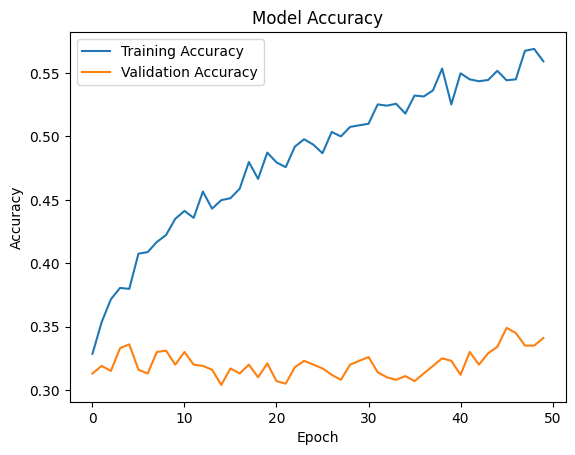

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load and preprocess data
df = pd.read_csv('/kaggle/input/viral-social-media-trends-and-engagement-analysis/Viral_Social_Media_Trends.csv')

# Feature engineering
df = pd.get_dummies(df, columns=['Platform', 'Content_Type', 'Region', 'Hashtag'])
engagement_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Engagement_Level'] = df['Engagement_Level'].map(engagement_map)

# Prepare features and target
X = df.drop(['Post_ID', 'Engagement_Level'], axis=1)
y = df['Engagement_Level']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build neural network
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, 
                    epochs=50, 
                    batch_size=32,
                    validation_data=(X_test, y_test))

# Evaluate model
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

# Make predictions
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

2. Content Recommendation System

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import numpy as np

# Content similarity analysis using SBERT
model = SentenceTransformer('all-MiniLM-L6-v2')

# Sample content data (in practice would come from your dataset)
content_samples = [
    "How to do the latest dance challenge",
    "Educational video about neural networks",
    "Tech review of the newest smartphone",
    "Fashion trends for this summer"
]

# Generate embeddings
content_embeddings = model.encode(content_samples)

# User preference vector (could be learned from history)
user_preference = model.encode("I enjoy dance challenges and tech reviews")

# Calculate similarity
similarities = cosine_similarity(
    [user_preference],
    content_embeddings
)[0]

# Recommend top content
recommended_indices = np.argsort(similarities)[::-1][:2]
print("Recommended content:")
for idx in recommended_indices:
    print(f"- {content_samples[idx]} (similarity: {similarities[idx]:.2f})")

OSError: We couldn't connect to 'https://huggingface.co' to load this file, couldn't find it in the cached files and it looks like sentence-transformers/all-MiniLM-L6-v2 is not the path to a directory containing a file named config.json.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

3. Optimal Posting Time Prediction

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import pandas as pd
from datetime import datetime

# Assuming we've added temporal features to our dataset
# df['Hour'] = ... extracted from timestamp
# df['DayOfWeek'] = ... extracted from timestamp

# Prepare temporal features
X_time = df[['Hour', 'DayOfWeek', 'Platform_encoded']]
y_time = df['Views']  # or other engagement metric

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_time, y_time, test_size=0.2)

# Hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf = RandomForestRegressor()
grid_search = GridSearchCV(rf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Best model
best_rf = grid_search.best_estimator_

# Predict optimal times
platforms = df['Platform'].unique()
optimal_times = {}

for platform in platforms:
    platform_data = df[df['Platform'] == platform]
    # Find hour with highest predicted engagement
    hours = range(24)
    predictions = []
    for hour in hours:
        test_case = pd.DataFrame({
            'Hour': [hour],
            'DayOfWeek': [2],  # Wednesday
            'Platform_encoded': [platform_encodings[platform]]
        })
        predictions.append(best_rf.predict(test_case)[0])
    
    optimal_hour = hours[np.argmax(predictions)]
    optimal_times[platform] = optimal_hour

print("Optimal posting times by platform:", optimal_times)

KeyError: "None of [Index(['Hour', 'DayOfWeek', 'Platform_encoded'], dtype='object')] are in the [columns]"

4. Sentiment Analysis for Content Optimization

In [35]:
from transformers import pipeline
import pandas as pd

# Initialize sentiment analysis pipeline
sentiment_analyzer = pipeline("sentiment-analysis")

# Sample comments (in practice would come from your dataset)
comments = [
    "This is amazing content! Love it!",
    "Not what I expected, pretty disappointed",
    "The tutorial was helpful but could be clearer",
    "Best challenge ever! Trying it now!"
]

# Analyze sentiment
results = sentiment_analyzer(comments)

# Combine with original comments
for comment, result in zip(comments, results):
    print(f"Comment: {comment}")
    print(f"Sentiment: {result['label']} (confidence: {result['score']:.2f})")
    print()

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


OSError: We couldn't connect to 'https://huggingface.co' to load this file, couldn't find it in the cached files and it looks like distilbert/distilbert-base-uncased-finetuned-sst-2-english is not the path to a directory containing a file named config.json.
Checkout your internet connection or see how to run the library in offline mode at 'https://huggingface.co/docs/transformers/installation#offline-mode'.

5. A/B Testing Simulation with Neural Networks

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Simulate A/B test data
np.random.seed(42)
n_samples = 1000

# Version A (control)
a_clicks = np.random.binomial(1, 0.1, n_samples)
a_views = np.ones(n_samples)

# Version B (variant)
b_clicks = np.random.binomial(1, 0.13, n_samples)  # Slightly better CTR
b_views = np.ones(n_samples)

# Prepare data for neural network
X = np.concatenate([np.zeros(n_samples), np.ones(n_samples)])  # 0=A, 1=B
y = np.concatenate([a_clicks, b_clicks])

# Simple neural network to model CTR
model = Sequential([
    Dense(16, activation='relu', input_shape=(1,)),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(learning_rate=0.01),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=20, batch_size=32, validation_split=0.2)

# Predict CTR difference
ctr_a = model.predict(np.array([0]))
ctr_b = model.predict(np.array([1]))
print(f"Predicted CTR for Version A: {ctr_a[0][0]:.2%}")
print(f"Predicted CTR for Version B: {ctr_b[0][0]:.2%}")
print(f"Estimated improvement: {(ctr_b[0][0]/ctr_a[0][0]-1):.2%}")